# Week 1: Exploratory Data Analysis (Iris and California Housing)

Note: Boston Housing was removed from scikit-learn (v1.2+), so California Housing is used instead.

In [1]:
import pandas as pd, numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_california_housing

iris = load_iris(as_frame=True).frame
housing = fetch_california_housing(as_frame=True).frame

## Part 1: Iris Dataset

In [2]:
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
iris.shape

(150, 5)

In [4]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
iris.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [7]:
iris["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

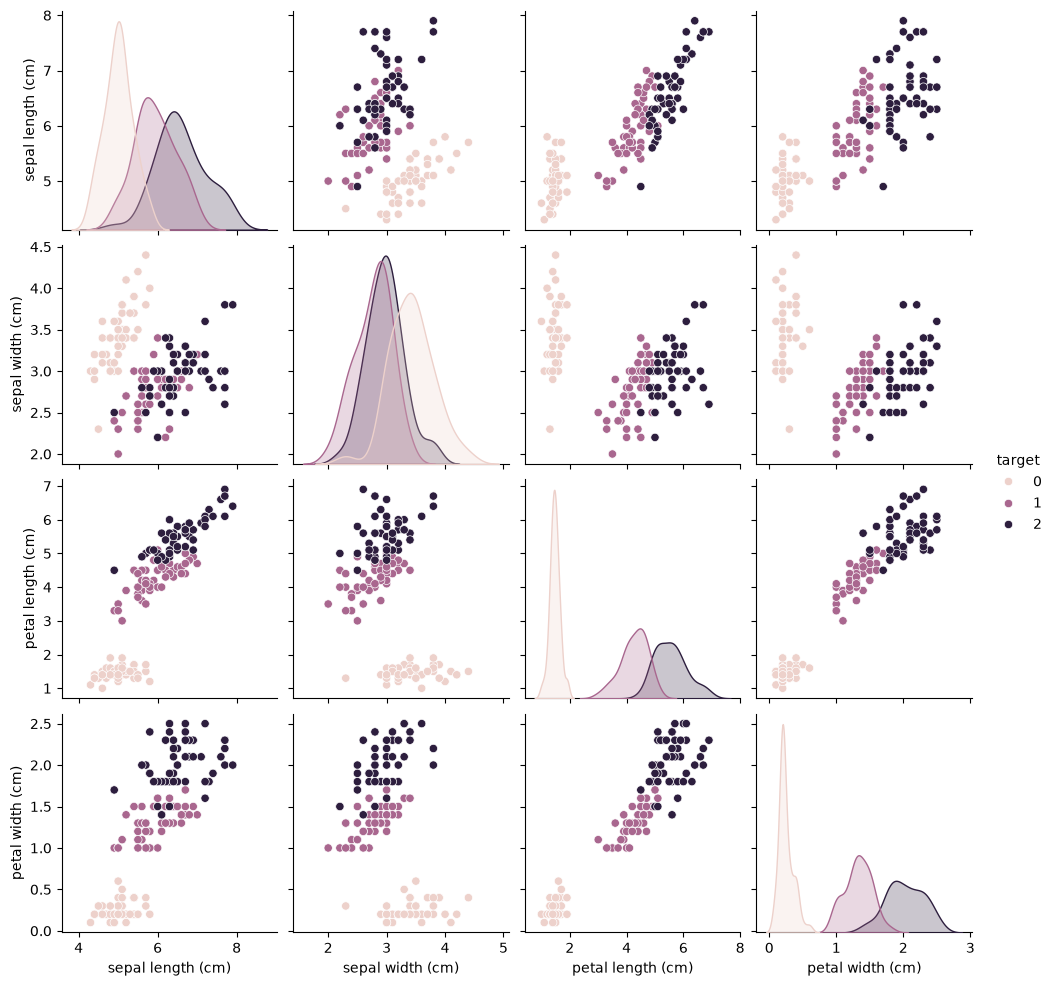

In [8]:
sns.pairplot(iris, hue="target")
plt.show()

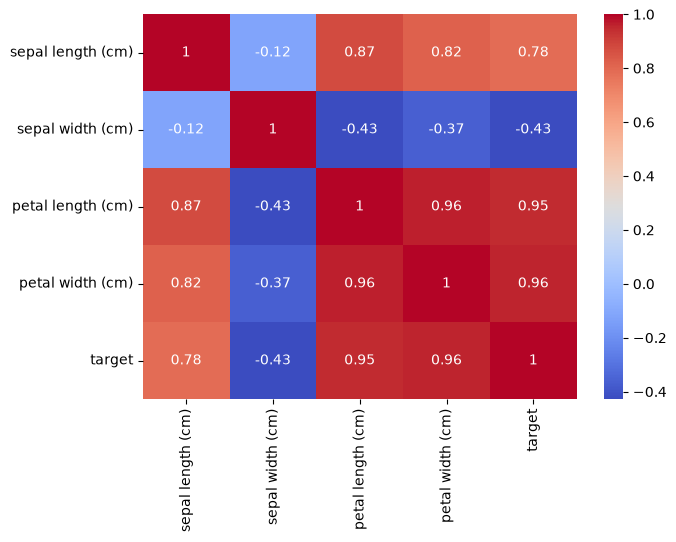

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(iris.corr(), annot=True, cmap="coolwarm")
plt.show()

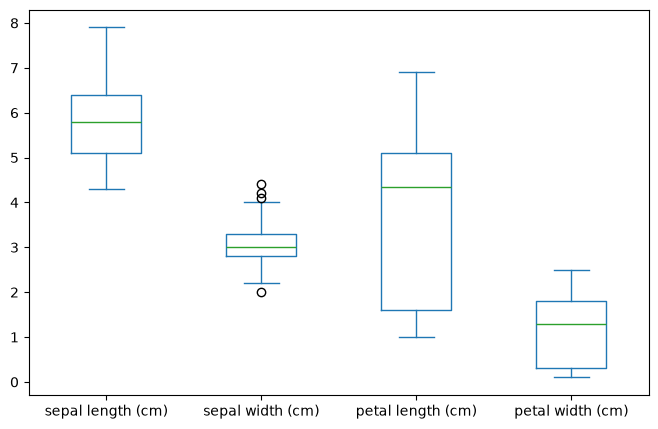

In [10]:
iris.drop(columns="target").plot(kind="box", figsize=(8, 5))
plt.show()

### Iris Dataset: Observations

**Dataset overview**
- The dataset has **150 rows and 5 columns** (4 numeric features: sepal length, sepal width, petal length, petal width, plus 1 target column).
- The target is `target` (the iris species), with **3 classes** (0, 1, 2). This is a **classification** problem.

**Data quality**
- There are **no missing values** (`isna().sum()` shows 0 for every column).
- The classes are **balanced**: each class has 50 samples, so accuracy is a fair metric for this dataset.

**Pairplot observations**
- Class 0 (setosa) is clearly separated from the other two classes, especially on petal length and petal width.
- Classes 1 and 2 overlap a little, so they are harder to separate than class 0.
- The petal features separate the classes better than the sepal features.

**Correlation observations**
- Petal length and petal width have a very strong positive correlation with the target (about 0.95 to 0.96).
- Petal length and petal width are also strongly correlated with each other.
- Sepal length has a strong positive correlation with the target (about 0.78), while sepal width has a moderate negative correlation (about -0.43).

**Outliers**
- The box plot shows a few outliers, mainly in `sepal width`. The other features have almost none.
- These are mild natural variation, so no removal is needed.

**Conclusion**
- Petal length and petal width are the most useful features for predicting the species.
- Since the data is clean and balanced, it is a good starting dataset for logistic regression.

## Part 2: California Housing Dataset

In [11]:
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
housing.shape

(20640, 9)

In [13]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [14]:
housing.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [15]:
housing.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

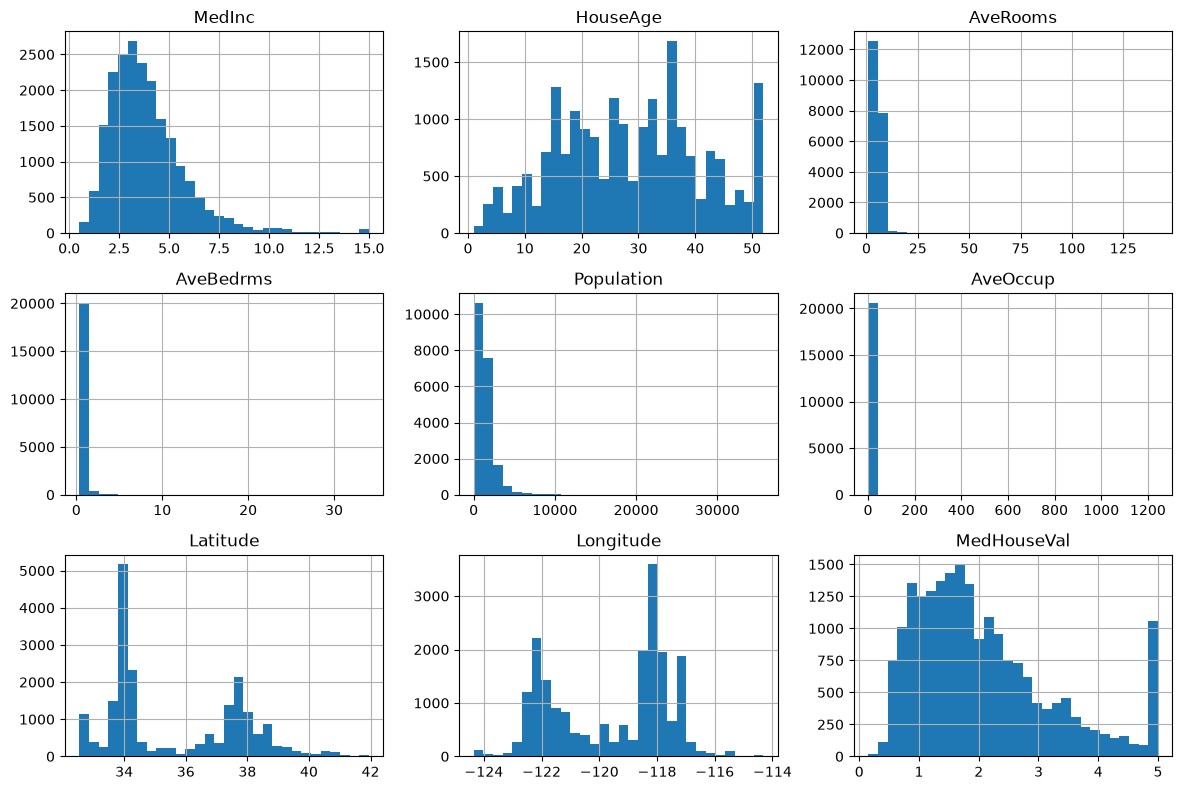

In [16]:
housing.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

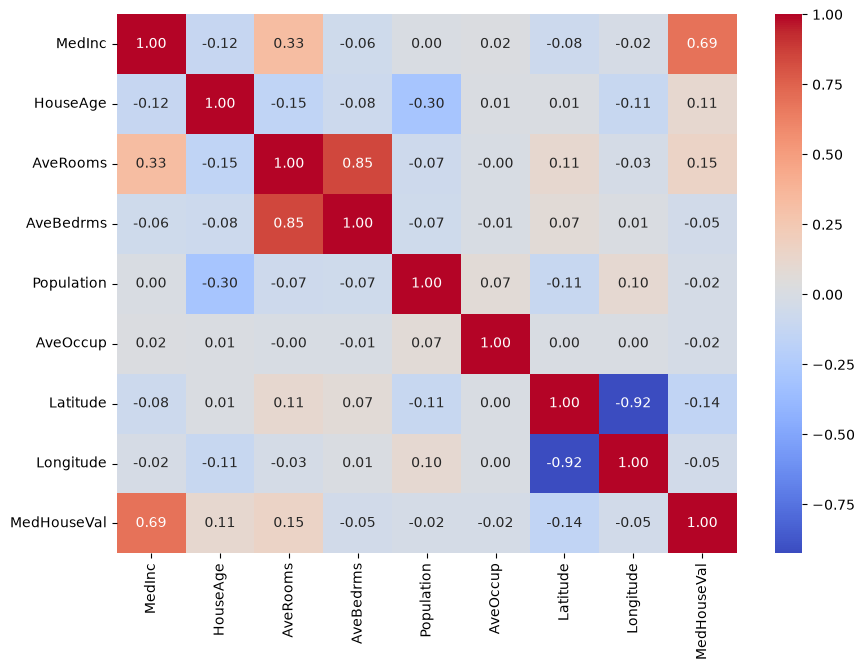

In [17]:
plt.figure(figsize=(10, 7))
sns.heatmap(housing.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [18]:
housing.corr()["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

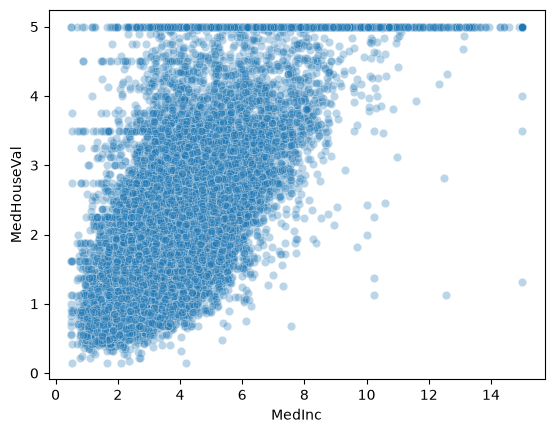

In [19]:
sns.scatterplot(data=housing, x="MedInc", y="MedHouseVal", alpha=0.3)
plt.show()

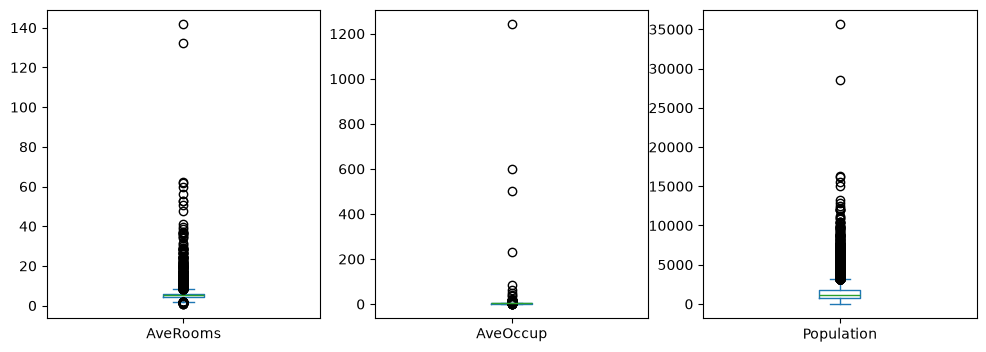

In [20]:
housing[["AveRooms", "AveOccup", "Population"]].plot(kind="box", subplots=True, figsize=(12, 4))
plt.show()

### California Housing Dataset: Observations

**Dataset overview**
- The dataset has **20,640 rows and 9 columns** (8 numeric features plus the target `MedHouseVal`).
- The target is `MedHouseVal` (median house value, in units of $100,000). It is a continuous number, so this is a **regression** problem.
- Features include `MedInc` (median income), `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude` and `Longitude`.

**Data quality**
- There are **no missing values**.
- `MedHouseVal` appears **capped at 5.0** (a spike at the right end of the histogram and a flat line at the top of the scatter plot). `HouseAge` is also capped (about 52).

**Correlation observations**
- `MedInc` has the strongest positive correlation with the target (about 0.69), so areas with higher income have more expensive houses.
- `AveRooms` has a weak positive correlation (about 0.15) and `Latitude` a weak negative correlation (about -0.14). `Population` and `AveOccup` are close to zero.
- Some features are strongly related to each other: `AveRooms` and `AveBedrms` are positively correlated, and `Latitude` and `Longitude` are strongly negatively correlated.

**Outliers**
- `AveRooms`, `AveOccup` and `Population` have very large outliers (max values far above the 75th percentile in `describe()`), likely from unusual areas such as vacation homes or large group housing.
- Features are on very different scales (`Population` in thousands, `MedInc` in single digits), so scaling is needed for gradient descent.

**Conclusion**
- `MedInc` is the most useful single predictor of house value.
- The price cap and outliers may limit a simple linear regression, which is evaluated with MSE and R² in the models notebook.